In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report 
import pickle
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data=pd.read_csv("churn.csv")

In [3]:
data.shape

(5000, 21)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           5000 non-null   str    
 1   Account Length  5000 non-null   int64  
 2   Area Code       5000 non-null   int64  
 3   Phone           5000 non-null   str    
 4   Int'l Plan      5000 non-null   str    
 5   VMail Plan      5000 non-null   str    
 6   VMail Message   5000 non-null   int64  
 7   Day Mins        5000 non-null   float64
 8   Day Calls       5000 non-null   int64  
 9   Day Charge      5000 non-null   float64
 10  Eve Mins        5000 non-null   float64
 11  Eve Calls       5000 non-null   int64  
 12  Eve Charge      5000 non-null   float64
 13  Night Mins      5000 non-null   float64
 14  Night Calls     5000 non-null   int64  
 15  Night Charge    5000 non-null   float64
 16  Intl Mins       5000 non-null   float64
 17  Intl Calls      5000 non-null   int64  
 18 

In [5]:
data.describe()

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,101.675800,773.791400,226.680000,5.518757,3.50460,5.018902,5.026199,3.140400,5.017557,4.000917,224.790000,5.023490,5.025876,5.475400,4.328242,5.525800
std,57.596762,63.470888,273.998527,3.433485,1.68812,2.195759,2.135487,2.525621,2.127857,1.631001,97.302875,1.748900,1.019302,1.877045,2.440311,2.041217
min,1.000000,657.000000,0.000000,0.000215,0.00000,0.004777,0.004659,0.000000,0.013573,0.008468,0.000000,0.054863,1.648514,0.000000,0.000769,0.000000
25%,52.000000,736.000000,0.000000,2.682384,2.00000,3.470151,3.588466,1.000000,3.529613,2.921998,150.000000,3.873157,4.349726,4.000000,2.468225,4.000000
50%,102.000000,778.000000,0.000000,5.336245,3.00000,4.988291,5.145656,3.000000,5.006860,3.962089,200.000000,5.169154,5.034905,5.000000,4.214058,6.000000
75%,151.000000,806.000000,400.000000,7.936151,5.00000,6.559750,6.552962,5.000000,6.491725,5.100128,300.000000,6.272015,5.716386,7.000000,5.960654,7.000000
max,200.000000,878.000000,1300.000000,16.897529,10.00000,12.731936,13.622097,14.000000,12.352871,10.183378,550.000000,10.407778,8.405644,12.000000,14.212261,13.000000


In [6]:
data.isnull().sum()

State             0
Account Length    0
Area Code         0
Phone             0
Int'l Plan        0
VMail Plan        0
VMail Message     0
Day Mins          0
Day Calls         0
Day Charge        0
Eve Mins          0
Eve Calls         0
Eve Charge        0
Night Mins        0
Night Calls       0
Night Charge      0
Intl Mins         0
Intl Calls        0
Intl Charge       0
CustServ Calls    0
Churn?            0
dtype: int64

In [7]:
data.fillna(data.mean(numeric_only=True),inplace=True)

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,PA,163,806,403-2562,no,yes,300,8.162204,3,7.579174,...,4,6.508639,4.065759,100,5.111624,4.928160,6,5.673203,3,True.
1,SC,15,836,158-8416,yes,no,0,10.018993,4,4.226289,...,0,9.972592,7.141040,200,6.436188,3.221748,6,2.559749,8,False.
2,MO,131,777,896-6253,no,yes,300,4.708490,3,4.768160,...,3,4.566715,5.363235,100,5.142451,7.139023,2,6.254157,4,False.
3,WY,75,878,817-5729,yes,yes,700,1.268734,3,2.567642,...,5,2.333624,3.773586,450,3.814413,2.245779,6,1.080692,6,False.
4,WY,146,878,450-4942,yes,no,0,2.696177,3,5.908916,...,3,3.670408,3.751673,250,2.796812,6.905545,4,7.134343,6,True.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,NH,4,787,151-3162,yes,yes,800,10.862632,5,7.250969,...,1,8.026482,4.921314,350,6.748489,4.872570,8,2.122530,9,False.
4996,SD,140,836,351-5993,no,no,0,1.581127,8,3.758307,...,7,1.328827,0.939932,300,4.522661,6.938571,2,4.600473,4,False.
4997,SC,32,836,370-3127,no,yes,700,0.163836,5,4.243980,...,3,2.340554,0.939469,450,5.157898,4.388328,7,1.060340,6,False.
4998,MA,142,776,604-2108,yes,yes,600,2.034454,5,3.014859,...,3,3.470372,6.076043,150,4.362780,7.173376,3,4.871900,7,True.


In [8]:
encoder=LabelEncoder()
for col in data.columns:
  if data[col].dtype=='str':
    data[col]=encoder.fit_transform(data[col])

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           5000 non-null   int64  
 1   Account Length  5000 non-null   int64  
 2   Area Code       5000 non-null   int64  
 3   Phone           5000 non-null   int64  
 4   Int'l Plan      5000 non-null   int64  
 5   VMail Plan      5000 non-null   int64  
 6   VMail Message   5000 non-null   int64  
 7   Day Mins        5000 non-null   float64
 8   Day Calls       5000 non-null   int64  
 9   Day Charge      5000 non-null   float64
 10  Eve Mins        5000 non-null   float64
 11  Eve Calls       5000 non-null   int64  
 12  Eve Charge      5000 non-null   float64
 13  Night Mins      5000 non-null   float64
 14  Night Calls     5000 non-null   int64  
 15  Night Charge    5000 non-null   float64
 16  Intl Mins       5000 non-null   float64
 17  Intl Calls      5000 non-null   int64  
 18 

In [10]:
print(data.head())

   State  Account Length  Area Code  Phone  Int'l Plan  VMail Plan  \
0     38             163        806   1685           0           1   
1     40              15        836    335           1           0   
2     24             131        777   4452           0           1   
3     50              75        878   3988           1           1   
4     50             146        878   1911           1           0   

   VMail Message   Day Mins  Day Calls  Day Charge  ...  Eve Calls  \
0            300   8.162204          3    7.579174  ...          4   
1              0  10.018993          4    4.226289  ...          0   
2            300   4.708490          3    4.768160  ...          3   
3            700   1.268734          3    2.567642  ...          5   
4              0   2.696177          3    5.908916  ...          3   

   Eve Charge  Night Mins  Night Calls  Night Charge  Intl Mins  Intl Calls  \
0    6.508639    4.065759          100      5.111624   4.928160           6   


<Axes: xlabel='Churn?', ylabel='count'>

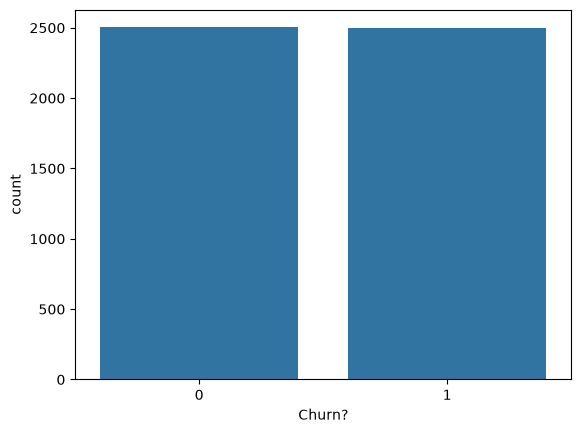

In [11]:
sns.countplot(
x="Churn?",
data=data)

In [12]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: >

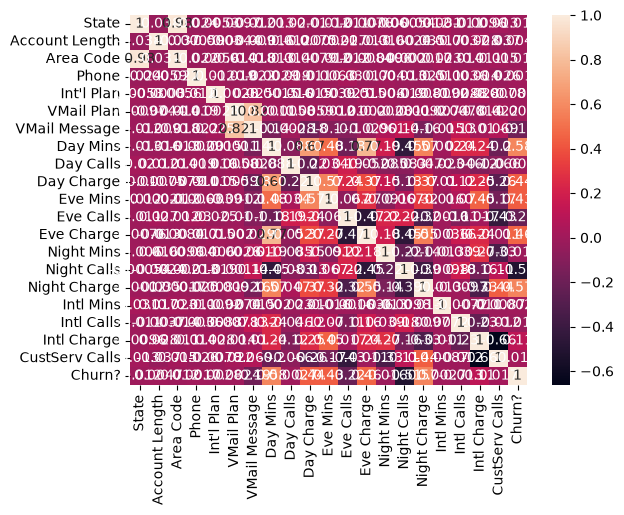

In [13]:
sns.heatmap(data.corr(),annot=True)

In [14]:
x=data.drop("Churn?",axis=1)

In [15]:
y=data["Churn?"]

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [22]:
model=LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [23]:
prediction=model.predict(x_test)
print(prediction)

[0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 0 0 1 0 1 1 0 1 0 1 1 1 0 0 1 1 1 0
 1 1 1 1 0 0 1 0 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 1 0 1 1 1 1 0
 1 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0
 1 1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 0 1 0 1 1 1 0 0 1 0 0 0
 0 1 1 0 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 0 1
 0 1 0 1 0 0 0 1 0 1 1 1 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0 1 1 0 1 1 0 1 0 1 0
 1 0 1 0 1 1 0 1 1 1 1 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1
 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 1
 0 0 1 1 1 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 1 0 0
 0 1 1 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 1 0 1 1 1 0
 1 1 0 0 0 1 1 0 0 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 1 1
 1 0 0 0 0 1 0 1 1 1 0 1 

In [24]:
accuracy=accuracy_score(
    y_test,
    prediction)
print("Accuracy:",accuracy)

Accuracy: 0.864


In [26]:
cm=confusion_matrix(
    y_test,
    prediction)

<Axes: >

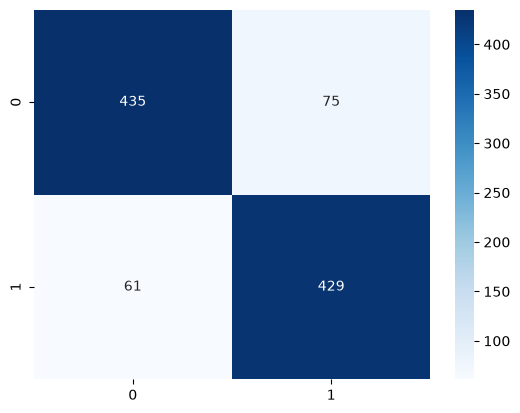

In [27]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

In [28]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[435  75]
 [ 61 429]]


In [29]:
print(
    classification_report(
        y_test,
    prediction)
    )

              precision    recall  f1-score   support

           0       0.88      0.85      0.86       510
           1       0.85      0.88      0.86       490

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



In [30]:
with open("churn_model.pkl","wb") as f:
  pickle.dump(model,f)
  print("Model saved successfully")
loaded_model=pickle.load(open("churn_model.pkl","rb"))
open(
    "churn_model.pkl",
    "rb"
)

Model saved successfully


<_io.BufferedReader name='churn_model.pkl'>

In [31]:
input_data = (6,128,415,1234,1,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1)


In [32]:
print(x.columns)
print(x.shape)

Index(['State', 'Account Length', 'Area Code', 'Phone', 'Int'l Plan',
       'VMail Plan', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
       'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
       'Night Charge', 'Intl Mins', 'Intl Calls', 'Intl Charge',
       'CustServ Calls'],
      dtype='str')
(5000, 20)


In [33]:
input_array=np.asarray(input_data)
input_reshaped=input_array.reshape(1,-1)
input_scaled=scaler.transform(input_reshaped)

C:\Users\ishant\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [35]:
result=loaded_model.predict(
  input_scaled
)

if result[0]==1:
  print("Customer will leave the company")
else:
  print("Customer will not leave the company")

Customer will leave the company
